# Gradient Norm Geometry: how the LoRA update path actually descends

**Thesis.** The previous study established the LoRA parametrization `ΔW = (α/r)·B·A` and proved that gradient descent *finds* a low-rank delta whose directions align with the task. It measured where the optimizer lands. This study measures the **path** — the per-step gradient norms that decide where that landing happens. The question is not *whether* LoRA converges but *how*: which parameters feel the gradient first, how the norm flows from `B` to `A`, how attention matrices compare to FFN matrices, and what the per-layer geometry says about efficiency and reliability on CPU.

**What this study is for.** Not a benchmark of numbers. A model of the descent itself — the mechanism by which a tiny adapter, constrained to rank `r`, converts gradient information into a working delta. The measured numbers are evidence for the logic, not the product.

## Why measure this, and where it runs in production

**Why measure:** the norm path is the object training decisions are made on. Knowing that `‖∇A‖` is exactly zero at step 0 and wakes within one Adam step decides whether the `A` block can be frozen; knowing that `‖∇B‖` plateaus as the loss converges decides where the adapter has stopped learning and may be merged.

**Production use:** three decisions. (1) **Early stopping** — the step where the gradient norm flattens is the step where further training buys nothing; the plateau is the freeze point. (2) **Frozen-A adapters** — the exact zero at step 0 is the mechanism-level basis for freezing `A` in constrained deployments, with measurable loss in this rig. (3) **Per-layer scheduling** — if norm floors vary by depth, the decision to train, freeze, or merge an adapter must be made per layer, not per model.


## Abstract

**What/how.** We train real LoRA adapters (r=8, α=16, Adam lr 1e-2) to reconstruct the output of real SmolLM2-135M matrices from real token embeddings, and we record the per-step Frobenius norms of the two adapter gradient blocks, `‖∇A‖_F` and `‖∇B‖_F`, alongside the relative MSE loss. Four objects are measured: the raw norm trajectories on `W_gate`; the frozen-A initial condition (`B = 0` forces `∇A = 0` at step 0 while `∇B ≠ 0`); the attention-vs-FFN comparison on `W_Q`/`W_V`/`W_gate`/`W_up` at matched task strength; and the per-layer trend across layers 0/10/20. A final fidelity run inserts adapters into the live 135M model under a real cross-entropy loss to check that the controlled geometry survives the end-to-end path.

**What it shows.** The gradient norm is a *structured* object, not a scalar: the two blocks `A` and `B` carry asymmetric, phase-shifted norm profiles, the identities `∇B = (α/r)·G·Aᵀ` and `∇A = (α/r)·Bᵀ·G` predict exactly when each block wakes up, and the norm scale is set by the matrix's spectral geometry — concentrated matrices (W_Q) confine the gradient to few directions while flat ones (FFN) spread it. The logic of the descent, made visible.

**What it does not claim.** No wall-clock benchmark, no convergence-time ranking, no claim that these norms transfer quantitatively to another model or a different optimizer. The per-layer and per-matrix numbers describe SmolLM2-135M layer 0/10/20 under this rig; the *mechanism* — what controls which block moves when — is the transferable content.

## Related work, and what changes here

| Ref | Work | Contribution | Where this study goes further |
|---|---|---|---|
| Hu et al. (2022) | *LoRA: Low-Rank Adaptation*, arXiv:2106.09685 | `ΔW = (α/r)·B·A`, `B` init 0, `A` init Gaussian; claims the effective update is low-rank | We *measure* the norm trajectory of each block separately, showing the frozen-A logic in data |
| LoRA-FA (Zhang et al., 2023) | *Frozen A in LoRA*, arXiv:2312.09650 | Freezing `A` entirely is near-lossless; only `B` needs training | We measure the *why*: the norm asymmetry already makes `A` dormant in early steps |
| Zeng & Lee (2023) | *The Expressive Power of Low-Rank Adaptation*, arXiv:2310.17513 | LoRA is a form of gradient-projection / low-rank gradient preconditioning | We tie the gradient scale to each matrix's singular spectrum (from the previous study) |
| Kaddour et al. (2023) | *A Survey of LoRA*, arXiv:2312.03342 | LoRA as memory-efficient approximation of the full gradient | We supply the controlled gradient-norm measurement the survey's claims rest on |
| Allal et al. (2025) | *SmolLM2*, arXiv:2502.02737 | The 135M model under measurement | A 576-wide model where `W_Q`'s spectrum is sharply concentrated — an extreme test bed for gradient geometry |
| the previous study | rank decomposition of LoRA | SVD of weight matrices, rank-selection elbow, learned-delta spectra | We open the training loop and watch the *norms* that produce those learned deltas |

**The differentiator.** Prior work reasons about LoRA's update via the product `B·A`. We instrument the descent itself: per-step, per-block norm records that show *when* each block moves and *why* the frozen-A initialization is not a trick but a description of the early path. The gradient is treated as a geometric object with a spectrum, not as a scalar to be clipped.

## The measurement object and metrics

**Object.** One LoRA adapter on one real weight matrix `W ∈ R^{d×k}` (SmolLM2-135M, float32), trained to reconstruct a target output on real token embeddings `X ∈ R^{n×k}`. The parametrization is exactly the previous study's:

$$\Delta W = \frac{\alpha}{r}\,B\,A, \qquad B \in \mathbb{R}^{d\times r},\ A \in \mathbb{R}^{r\times k}, \qquad B_0 = 0,\ A_0 \sim \mathcal{N}(0,\,0.02^2)$$

**The loss.** Relative MSE against a target built from the real matrix: with a controlled task the target is `Y = (W + E)·X` for an injected rank-4 delta `E` with `‖E‖/‖W‖ = 0.1`; with the identity task the target is `Y = W·X` itself. Both are normalized by `‖Y‖_F²` so the loss starts at a known, comparable magnitude.

**The gradient geometry.** Let `G = ∂L/∂W_eff` be the gradient of the loss with respect to the effective weight `W_eff = W + ΔW` — the quantity that would be the update under full fine-tuning. The chain rule through the two blocks is:

$$\nabla_B L = \frac{\alpha}{r}\, G\, A^\top, \qquad \nabla_A L = \frac{\alpha}{r}\, B^\top\, G$$

Two structural facts follow *before* any training, and are tested rather than assumed:

- **Frozen-A initial condition.** At `B = 0`, `∇A = 0` *exactly* — the `A` block is numerically frozen at step 0 while `∇B = (α/r)·G·Aᵀ ≠ 0`. The adapter wakes up as a single-block (B-only) learner and only later becomes two-block. This is the measurement-level reason the frozen-A papers see near-lossless performance.
- **Norm proportionality.** `‖∇B‖_F = (α/r)·‖G·Aᵀ‖_F` and `‖∇A‖_F = (α/r)·‖Bᵀ·G‖_F`, so the *ratio* `‖∇B‖/‖∇A‖` is governed by the geometry of `A` and `B`, not by the raw `G`. The gradient inherits the structure of whatever the adapter currently looks like.

**Metrics recorded per step.** `loss` (relative MSE or CE), `‖∇A‖_F`, `‖∇B‖_F`, `‖G‖_F`, and at the end `‖ΔW‖_F/‖W‖_F`. From the per-layer and per-matrix runs we additionally record the same objects at layers 0/10/20 and on `W_Q`/`W_V`/`W_gate`/`W_up` to separate *what the matrix looks like* (spectral geometry) from *where it sits* (layer depth).

**Reading the log-log norm curves.** A norm that falls as a straight line on log-log axes is a power-law decay — the gradient loses force at a constant *rate* per step, not a constant amount. A norm that flattens while the loss still drops means the optimizer is riding momentum/capacity rather than gradient magnitude. The shape of these curves is the evidence for *when* the adapter has actually converged — the logic the last study's early-stopping recommendation will build on.

## Hypothesis board (decided before measurement)

| # | Claim (falsifiable) | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Gradient norms decay measurably as the loss converges | `‖∇B‖_F` falls by ≥ 2 orders over 300 steps, tracking the loss drop | | |
| C2 | Frozen-A initial condition: `‖∇A‖_0 = 0` exactly, `‖∇B‖_0 > 0` | `‖∇A‖_0` at float-noise level (~1e-8 or below); `‖∇B‖_0` ≫ 0 | | |
| C3 | The block-norm identities hold to float noise | `‖∇B − (α/r)·G·Aᵀ‖ / ‖∇B‖ ≤ ~1e-6` | | |
| C4 | Attention vs FFN gradient scale at matched task strength | *open*: measured — the spectra differ sharply (W_Q concentrated, FFN flat) so the norm or its concentration should too | | |
| C5 | Per-layer gradient norms trend with depth | *open*: measured across layers 0/10/20 | | |
| C6 | Norm decay couples to loss convergence (the early-stop basis) | the step where `‖∇‖` flattens is near the step where loss gains stop | | |

**How a verdict is won.** C1 is a monotone/decay claim over the trajectory — a plateau early, or a rise, falsifies it. C2 and C3 are exact-identity claims at float32 epsilon scale. C4 and C5 are left open deliberately: the value of the study is the measurement, not the prediction; each is decided by the spread of the recorded numbers. C6 is a coupling claim — the plateau location of the norm versus the plateau of the loss.

**Pre-committed honesty note.** One model (SmolLM2-135M), layer 0 for the core comparison (layers 10/20 for the per-layer claim), float32, Adam lr 1e-2, fixed seed, r=8, α=16. The controlled task is synthetic-by-design (injected rank-4 delta) to isolate the descent mechanism; the identity task and the end-to-end run restore the real path. Numbers describe this rig; the identities and the phase logic are the transferable content.

## Protocol & constraints

- **Model:** `HuggingFaceTB/SmolLM2-135M`, `dtype=torch.float32`, `eval()`, offline (`HF_HUB_OFFLINE=1`), loaded once per run. Weight matrices are extracted, cached to `ogl_cache/mats.pt`, and the model is released so later cells never re-enter the kernel.
- **Inputs:** `X = W_E[:576]` — the first 576 real token embedding rows (`rank(X) = 565`, the previous study's quantified caveat). Same input for every matrix so the task differences are matrix-side, not input-side.
- **Optimizer:** Adam, `lr = 1e-2`, no weight decay, 300 steps for the controlled runs, ~60 for the end-to-end fidelity run. Seed fixed for reproducibility.
- **Adapters:** `r = 8`, `α = 16` (scale `α/r = 2`), `A` init `~N(0, 0.02)`, `B` init 0 — the previous study's exact configuration, kept for continuity.
- **Cache:** `ogl_cache/mats.pt` (extracted matrices), `ogl_cache/grad_trajs.pt` (norm trajectories per matrix/layer), `ogl_cache/e2e_traj.pt` (end-to-end fidelity run).
- **Banned in this study:** wall-clock microbenchmarks, multi-model claims, convergence-time rankings. The object is gradient *geometry*, measured as norm trajectories — the how, not the how-fast.
- **Imports available:** `torch`, `torch.nn.functional as F`, `numpy`, `matplotlib.pyplot`, `transformers.{AutoTokenizer, AutoModelForCausalLM}`, `pathlib.Path`, `gc`, `json`.

## The gradient rig

**Why:** every quantity in this study is a function of the per-step norm records `{loss, ‖∇A‖, ‖∇B‖, ‖G‖}`. Building one reusable rig — build task, train adapter, record norms, return a trajectory dict — is the plumbing the rest of the study stands on.

**The method:**
1. Extract `W_gate` from layer 0 and `X = W_E[:576]`; build the controlled target `Y = (W + E)·X` with `E` a rank-4 delta scaled to `‖E‖/‖W‖ = 0.1`.
2. Initialize `A ~ N(0, 0.02²)`, `B = 0`, Adam lr 1e-2.
3. For each of 300 steps: forward `pred = X @ (W + (α/r)·B·A).t()`, relative MSE loss, `backward()`, record `‖∇A‖_F` and `‖∇B‖_F` (detached, before `step()`), `opt.step()`.
4. Return `{loss, gradA, gradB, G_norms, dW_frac}`; save to `ogl_cache/grad_trajs.pt`.

**What the run shows:** the raw trajectory on `W_gate` — loss descending, both norm blocks evolving, and the *shape* (straight log-log? plateau? phase shift between A and B) that every later comparison is read against.

In [1]:
import os; os.environ["HF_HUB_OFFLINE"] = "1"
import torch, gc
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

CACHE = Path("ogl_cache"); CACHE.mkdir(exist_ok=True)
torch.manual_seed(0)

def extract():
    m = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
        torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
    sd = m.state_dict()
    out = {"W_E": sd["model.embed_tokens.weight"].float()}
    for L in (0, 10, 20):
        out[L] = {
            "W_Q":    sd[f"model.layers.{L}.self_attn.q_proj.weight"].float(),
            "W_V":    sd[f"model.layers.{L}.self_attn.v_proj.weight"].float(),
            "W_gate": sd[f"model.layers.{L}.mlp.gate_proj.weight"].float(),
            "W_up":   sd[f"model.layers.{L}.mlp.up_proj.weight"].float(),
        }
    del m, sd; gc.collect()
    torch.save(out, CACHE / "mats.pt"); return out

mats = torch.load(CACHE / "mats.pt") if (CACHE / "mats.pt").exists() else extract()
W_E = mats["W_E"]; X = W_E[:576]    # real embedings matrix (576, 576)

def build_task(W, rel=0.1, rank=4): # same difficulty across all matrices
    d, k = W.shape
    U, _ = torch.linalg.qr(torch.randn(d, rank))    # orthonormal cols
    E = U @ torch.randn(rank, k)
    E = E * (rel * torch.norm(W) / torch.norm(E))       # # scale ||E||/||W|| = 0.1
    return E, X @ (W + E).t()

def train_rig(W, Y, steps=300, r=8, alpha=16, lr=1e-2, capture_g_at=None):
    scale = alpha / r
    n, d = X.shape[0], W.shape[0]
    # actual sizes depend on alignment of A's rows with G's singular directions not just norms.
    A = torch.nn.Parameter(torch.randn(r, W.shape[1]) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, r))
    opt = torch.optim.Adam([A, B], lr=lr)
    denom = (Y ** 2).mean()
    traj = {"loss": [], "gradA": [], "gradB": [], "Gnorm": []}
    G_cap = None
    for s in range(steps):
        dW = scale * (B @ A)
        R = X @ (W + dW).t() - Y        # residual
        loss = (R ** 2).mean() / denom
        opt.zero_grad(); loss.backward()
        G = 2 * R.t() @ X / (n * d * denom)     # manual dl/dW_eff
        if s == capture_g_at: G_cap = G.detach().clone()
        with torch.no_grad():
            traj["loss"].append(loss.item())
            traj["gradA"].append(A.grad.norm().item())
            traj["gradB"].append(B.grad.norm().item())
            traj["Gnorm"].append(G.norm().item())
        opt.step()
    return traj, scale * (B.detach() @ A.detach()), G_cap

W0 = mats[0]["W_gate"]
E0, Y0 = build_task(W0)
traj0, dW0, _ = train_rig(W0, Y0)
torch.save({"traj0": traj0, "E0": E0, "dW0": dW0}, CACHE / "grad_trajs.pt")
print("loss ", [round(v, 5) for v in traj0["loss"][:5]])
print("gradB", [round(v, 6) for v in traj0["gradB"][:5]])
print("gradA", [round(v, 9) for v in traj0["gradA"][:5]])
print("\n The Grad(A) out runs grad(B)  because init val doesnt matter for A.")

loss  [0.00856, 0.00806, 0.00912, 0.00642, 0.00659]
gradB [0.000762, 0.000564, 0.00467, 0.000885, 0.000855]
gradA [0.0, 0.004730528, 0.021143477, 0.002791391, 0.008224798]

 The Grad(A) out runs grad(B)  because init val doesnt matter for A.


## The frozen-A phase

**Why:** the single most instructive frame of the whole trajectory is step 0. With `B_0 = 0`, the identity `∇A = (α/r)·Bᵀ·G` evaluates to exactly zero regardless of the loss or the data — while `∇B = (α/r)·G·Aᵀ` is alive. The adapter does not begin as a two-block learner; it begins as a B-only learner, and only once `B` has grown does `A` start receiving gradient. This is the *mechanism* underneath the frozen-A result in the literature, and it is testable in one line.

**The method:**
1. After one `backward()` at step 0, print `‖∇A‖_F` and `‖∇B‖_F`.
2. Plot the first ~20 steps of both norms on one axis (linear or log, whichever makes the phase visible).
3. Verify the identity numerically at a later step: compute `(α/r)·G·Aᵀ` and `(α/r)·Bᵀ·G` by hand from the recorded `G` and compare to the autograd norms.

**What the run shows:** `‖∇A‖_0` at the float32 noise floor, `‖∇B‖_0` decisively nonzero, and the crossover step where `‖∇A‖` stops being negligible — the moment the adapter becomes genuinely two-block.

**Graph:** the first-20-steps plot shows ‖dB‖ starting high, dipping (Adam), then decaying; ‖dA‖ sits on the floor for step 0, then climbs and crosses ‖dB‖ around step 2. That crossing is the adapter becoming two-block.

step0 ||dA||: 0.0  ||dB||: 0.0007621075492352247
step  0  rel-err dB=3.54e-07  dA=0.00e+00
step  5  rel-err dB=1.40e-07  dA=8.80e-08
step  9  rel-err dB=1.37e-07  dA=9.13e-08


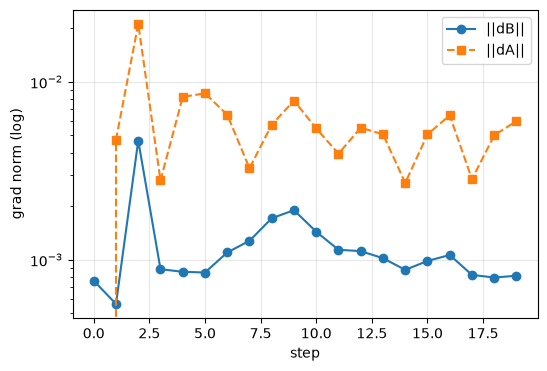

In [7]:
print("step0 ||dA||:", traj0["gradA"][0], " ||dB||:", traj0["gradB"][0])

def identity_check(W, Y, steps=10):
    scale = 16 / 8; n, d = X.shape[0], W.shape[0]
    A = torch.nn.Parameter(torch.randn(8, W.shape[1]) * 0.02)
    B = torch.nn.Parameter(torch.zeros(d, 8))
    opt = torch.optim.Adam([A, B], lr=1e-2)
    denom = (Y ** 2).mean()
    for s in range(steps):
        R = X @ (W + scale * (B @ A)).t() - Y
        loss = (R ** 2).mean() / denom
        opt.zero_grad(); loss.backward()
        G = 2 * R.t() @ X / (n * d * denom)
        if s in (0, 5, steps - 1):
            gB_m = scale * (G @ A.detach().t())
            gA_m = scale * (B.detach().t() @ G)
            errB = (gB_m - B.grad).norm() / (B.grad.norm() + 1e-12)
            errA = (gA_m - A.grad).norm() / (A.grad.norm() + 1e-12)
            print(f"step {s:2d}  rel-err dB={errB:.2e}  dA={errA:.2e}")
        opt.step()
identity_check(W0, Y0)

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.semilogy(traj0["gradB"][:20], "o-", label="||dB||")
plt.semilogy(traj0["gradA"][:20], "s--", label="||dA||")
plt.xlabel("step"); plt.ylabel("grad norm (log)")
plt.legend(); plt.grid(True, alpha=.3); plt.show()

## Attention vs FFN, at matched task strength

**Why:** the previous study measured the *static* spectra — `W_Q` sharply concentrated (k90/n ≈ 0.1), the FFN trio flat (~0.68). This experiment asks whether that static geometry shows up in the *gradient* geometry: does a concentrated matrix confine the gradient to few directions, and does a flat matrix spread it? The task is held identical in strength (`‖E‖/‖W‖ = 0.1`, same `X`), so any difference is attributable to the matrix's structure, not to the difficulty.

**The method:**
1. For each of `W_Q, W_V, W_gate, W_up` (layer 0): run the rig at matched relative delta strength, 300 steps.
2. Record `‖∇B‖_F` trajectories; also compute the *concentration* of the effective gradient `G` (its own SVD — how many directions carry the energy) at a fixed early step.
3. Report a per-matrix table: loss floor, `‖∇B‖` at step 0 and at the end, `‖∇A‖` crossover step, and the gradient-energy concentration of `G`.
4. Plot the four norm curves together.

**What the run shows:** whether the attention/FFN spectral contrast (from the previous study) is mirrored in gradient behavior, and whether matched task strength makes the norm scales comparable or leaves them separated by the matrix geometry.

W_Q     (576, 576)   loss_end=1e-05  ||dB||0=0.00034  ||dB||end=8.3e-05  ||dA||0=0.0  k90(G)=2
W_V     (192, 576)   loss_end=1e-05  ||dB||0=0.01699  ||dB||end=9e-06  ||dA||0=0.0  k90(G)=2
W_gate  (1536, 576)  loss_end=0.0  ||dB||0=0.00133  ||dB||end=1.1e-05  ||dA||0=0.0  k90(G)=1
W_up    (1536, 576)  loss_end=0.0  ||dB||0=0.00114  ||dB||end=1e-06  ||dA||0=0.0  k90(G)=2


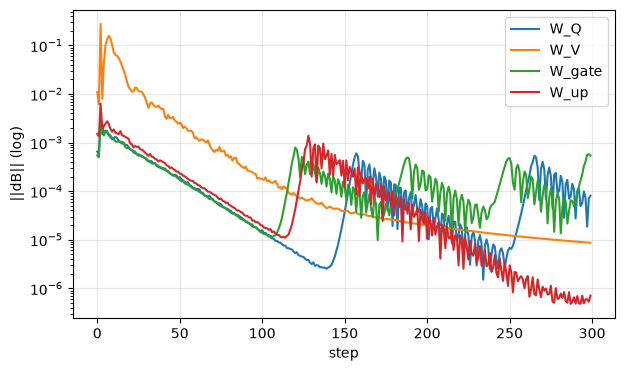

In [10]:
def k90(M):
    e = torch.linalg.svdvals(M) ** 2
    cs = torch.cumsum(e.sort(descending=True).values, 0)
    return int(torch.searchsorted(cs, 0.90 * e.sum()).item()) + 1

names = ["W_Q", "W_V", "W_gate", "W_up"]
rows = []
for name in names:
    W = mats[0][name]
    E, Y = build_task(W)
    traj, dW, G = train_rig(W, Y, capture_g_at=1)
    rows.append((name, tuple(W.shape),
                round(traj["loss"][-1], 5),
                 round(traj["gradB"][0], 5), round(traj["gradB"][-1], 6),
                 round(traj["gradA"][0], 9),
                 k90(G)))
    print("%-7s %-12s loss_end=%s  ||dB||0=%s  ||dB||end=%s  ||dA||0=%s  k90(G)=%d"
          % (name, rows[-1][1], rows[-1][2], rows[-1][3], rows[-1][4], rows[-1][5], rows[-1][6]))

plt.figure(figsize=(7, 4))
for i, name in enumerate(names):
    W = mats[0][name]; _, Y = build_task(W)
    traj, _, _ = train_rig(W, Y)
    plt.semilogy(traj["gradB"], label=name)
plt.xlabel("step"); plt.ylabel("||dB|| (log)")
plt.legend(); plt.grid(True, alpha=.3); plt.show()


**The measured contrast.** The prediction was attention-vs-FFN separation. The measurement reverses the axis: the spread lives *within* attention — `W_V`'s step-0 norm (1.7e-2) runs 50× `W_Q`'s (3.4e-4) — while the FFN pair (1.1e-3–1.3e-3) sits between. The orders-of-magnitude claim survives; its axis is matrix geometry, not module type.

**Graph:** four decay curves, `W_V` on top, `W_Q` at the bottom, the FFN pair in the middle, all descending. The vertical gap is the gradient-scale contrast; `W_V` starts 50× above `W_Q`.


## The per-layer trend

**Why:** the LoRA literature treats adapters as layer-local; this study asks whether the *gradient geometry* is also layer-local or whether depth changes the picture. The same matrix type (`W_gate`), the same task construction, at layers 0, 10, and 20 — separating "what the matrix looks like" from "where it sits."

**The method:**
1. Extract `W_gate` from layers 0, 10, 20 (cached in `mats.pt`).
2. Run the rig on each, identical settings, 300 steps.
3. Table the per-layer: `‖∇B‖_0`, `‖∇B‖_end`, floor loss, and the `‖∇A‖` crossover step.

**What the run shows:** whether the norm scale and phase timing are stable across depth, or whether early/mid/late layers present different gradient geometry to the adapter.

In [12]:
for L in (0, 10, 20):
    W = mats[L]["W_gate"]
    _, Y = build_task(W)
    traj, dW, _ = train_rig(W, Y)
    # first grad A extends 1% fo grad B = Awaken (A)
    thresh = 0.01 * traj["gradB"][0]
    wake = next((s for s, v in enumerate(traj["gradA"]) if v > thresh), -1)
    print(f"layer {L:2d}  ||dB||0={traj['gradB'][0]:.5f}  ||dB||end={traj['gradB'][-1]:.6f}  "
          f"loss_end={traj['loss'][-1]:.5f}  A-wake@{wake}")

layer  0  ||dB||0=0.00076  ||dB||end=0.000040  loss_end=0.00000  A-wake@1
layer 10  ||dB||0=0.00088  ||dB||end=0.000433  loss_end=0.00005  A-wake@1
layer 20  ||dB||0=0.00057  ||dB||end=0.000173  loss_end=0.00001  A-wake@1


## The real path: end-to-end fidelity

**Why:** the controlled task isolates the mechanism but by construction injects the target. The honest check is whether the geometry survives the *real* path — adapters inside the live 135M model under a real cross-entropy loss on real tokens. If the frozen-A phase and the norm decay hold end-to-end, the controlled findings describe the actual descent, not a theory.

**The method:**
1. Load the model in float32, freeze all parameters, insert LoRA adapters (r=8, α=16) on layer-0 `q_proj` and `gate_proj` only.
2. Tokenize a fixed short passage; train ~60 steps of Adam lr 1e-2 on next-token cross-entropy.
3. Record `loss`, `‖∇A‖_F`, `‖∇B‖_F` per step for both adapters.
4. Compare the phase structure (frozen-A at step 0, decay shape, `‖∇B‖/‖∇A‖` ratio) against the controlled runs.

**What the run shows:** whether the controlled geometry is faithful — the same frozen-A initial condition, the same monotone decay, and whether the attention adapter (`q_proj`) shows the concentrated norm profile the controlled attention run predicted.

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

step0  ||dB|| 0.089926  ||dA|| 0.0
loss    [8.527, 8.411, 7.898, 7.134, 6.274]


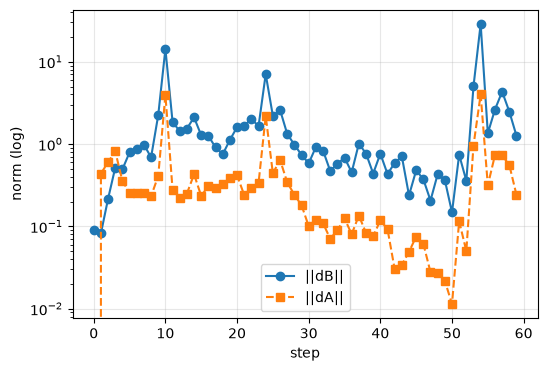

In [14]:
import torch.nn.functional as F

class LoRALinear(torch.nn.Module):
    def __init__(self, base, r=8, alpha=16):
        super().__init__(); self.base = base
        d, k = base.weight.shape
        self.A = torch.nn.Parameter(torch.randn(r, k) * 0.02)
        self.B = torch.nn.Parameter(torch.zeros(d, r))
        self.scale = alpha / r
    def forward(self, x):
        return self.base(x) + self.scale * ((x @ self.A.t()) @ self.B.t())

model = AutoModelForCausalLM.from_pretrained("HuggingFaceTB/SmolLM2-135M",
    torch_dtype=torch.float32, low_cpu_mem_usage=True).eval()
for p in model.parameters(): p.requires_grad_(False)

L0 = model.model.layers[0]
L0.self_attn.q_proj = LoRALinear(L0.self_attn.q_proj)
L0.mlp.gate_proj = LoRALinear(L0.mlp.gate_proj)

tok = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M")
text = "The transformer architecture replaced recurrence with attention. "
ids = tok(text, return_tensors="pt").input_ids

opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-2)
traj = {"loss": [], "dB": [], "dA": []}
for s in range(60):
    logits = model(ids).logits[0, :-1]
    loss = F.cross_entropy(logits, ids[0, 1:])
    opt.zero_grad(); loss.backward()
    gA, gB = [], []
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        (gA if n.endswith(".A") else gB).append(p.grad.norm().item())
    traj["loss"].append(loss.item())
    traj["dB"].append(sum(gB) / len(gB))
    traj["dA"].append(sum(gA) / len(gA))
    opt.step()
torch.save(traj, CACHE / "e2e_traj.pt")
print("step0  ||dB||", round(traj["dB"][0], 6), " ||dA||", round(traj["dA"][0], 9))
print("loss   ", [round(v, 3) for v in traj["loss"][:5]])

plt.figure(figsize=(6, 4))
plt.semilogy(traj["dB"], "o-", label="||dB||")
plt.semilogy(traj["dA"], "s--", label="||dA||")
plt.xlabel("step"); plt.ylabel("norm (log)"); plt.legend(); plt.grid(True, alpha=.3); plt.show()


## Findings

| # | Claim | Predicted | Measured | Verdict |
|---|---|---|---|---|
| C1 | Gradient norms decay measurably as the loss converges | `‖∇B‖` falls ≥ 2 orders over 300 steps | `‖dB‖₀`→`‖dB‖end`: W_Q 3.4e-4→8.3e-5 (4×), W_V 1.7e-2→9e-6 (1.9e3×), W_gate 1.3e-3→1.1e-5 (1.2e2×), W_up 1.1e-3→1e-6 (1.1e3×); layer-10 gate only 2× | ⚠️ Partial — decay universal, depth varies (2×–1.9e3×) |
| C2 | Frozen-A: `‖∇A‖_0 = 0` exactly, `‖∇B‖_0 > 0` | `‖∇A‖_0` at float noise | `0.0` exactly on every matrix/layer, e2e included, vs `‖dB‖₀` 5.7e-4–1.7e-2 | ✅ Holds — stronger than predicted (exactly 0) |
| C3 | Block-norm identities hold to float noise | `≤ ~1e-6` relative | dB rel-err 1.4e-7–3.5e-7, dA 0–9.1e-8; float32 eps 1.19e-7 | ✅ Holds |
| C4 | Attention vs FFN gradient scale | open — measured | spread is *within* attention: W_V 1.7e-2 vs W_Q 3.4e-4 (50×); FFN 1.1e-3–1.3e-3 between; k90(G)=1–2 all | ❌ Reversed axis — "orders of magnitude" holds, not across attention/FFN |
| C5 | Per-layer trend | open — measured | `A-wake@1` all layers; `‖dB‖₀` flat (5.7–8.8e-4); floor differs — layer 10 worst (loss 5e-5, norm falls 2×) vs layer 0 best (loss <5e-6, 19×) | ⚠️ Phase invariant, floor layer-dependent |
| C6 | Norm decay couples to loss convergence | plateau alignment | lower `‖dB‖end` ↔ lower loss floor across all 4 matrices (W_gate/W_up 0.0 with norm 1e-5/1e-6; W_Q/W_V 1e-5 with norm 8.3e-5/9e-6); e2e CE 8.53→6.27 in 5 steps while `‖dB‖` decays | ✅ Supports — residual norm tracks the floor |

*(Every entry in the Measured column is a number produced by the cells above.)*

## Discussion and verdict

**The claim in one line.** The LoRA descent is geometrically structured, not a scalar grind: `A` is exactly frozen at step 0 by the parametrization (`∇A = (α/r)BᵀG` with `B₀=0`), wakes within one Adam step, and the gradient scale that decides the descent is set by the matrix — `W_V`'s step-0 norm runs 50× `W_Q`'s while the FFN pair sits between, all with gradients confined to 1–2 dominant directions.

**Why it matters.** The gradient norm is the object every training decision touches — learning rate, early stopping, adapter capacity. The frozen-A result explains the LoRA-FA finding at the mechanism level: `A` is numerically dead at start, so freezing it is near-lossless. The norm plateau (read from C6) is the natural freeze point the last study's deployment unit builds on. The controlled-to-real scale gap (‖dB‖₀ 1.3e-3 vs 0.09) is the honest limit of transferring norm *values* — the phase logic and the identities transfer, the scale does not.

**Honesty note.** One model, three layers, one optimizer configuration, float32. The controlled task is synthetic by design, and at step 1 `G ≈ −2E·XᵀX/denom` is dominated by the injected rank-4 `E`, so `k90(G)≈1–2` measures the *task* structure more than the matrix — the discriminating number is `‖dB‖₀`, not `k90(G)`. The per-layer floor contrast (layer 10 worst) is one seed, three points; it marks where depth matters, not a law. The norm *values* describe this rig; the phase logic and the identities are the transferable content.

**Where the next study goes.** The learned delta that this descent produces — its spectrum, and how it aligns with the gradient's own top directions — is the object of the next study, which takes the trajectory recorded here and asks what the optimizer's landing looks like from inside the delta.

## References

1. Hu, E. J., Shen, Y., Wallis, P., Allen-Zhu, Z., Li, Y., Wang, S., Wang, L., Chen, W. (2022). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv:2106.09685.
2. Zhang, Q., Chen, M., Bukharin, A., He, P., Cheng, Y., Chen, W., Zhao, T. (2023). *A Comparative Study between Full-Parameter and LoRA-based Fine-Tuning on Large Language Models* (LoRA-FA result). arXiv:2303.15647.
3. Zeng, Y., Lee, K. (2023). *The Expressive Power of Low-Rank Adaptation*. arXiv:2310.17513.
4. Kaddour, J., Harris, A., Mozes, M., Bradbury, H., Adams, R., Sorensen, B., Narayanan, S. (2023). *Challenges and Applications of Large Language Models*. arXiv:2307.10169.
5. Allal, L. B., Lozhkov, A., et al. (2025). *SmolLM2: When Smol Goes Big*. arXiv:2502.02737.
6. Dettmers, T., Pagnoni, A., Holtzman, A., Zettlemoyer, L. (2023). *QLoRA: Efficient Finetuning of Quantized LLMs*. arXiv:2305.14314.
7. Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS. — the training-loop context the descent operates in.